# STAGE B→C1 — 모델 다양성 + 힐클라이밍 블렌드

> 로드맵 **STAGE B(모델 다양성) → C1(앙상블)**. 포화된 단일 GBDT 위에서 점수는 **다른 모델이 다르게 틀리는 방식**에서 나온다.
>
> **전제(확정):** baseline OOF AUC ≈ 0.7397. 연구 피처(H1/H3/H4/H5)는 ablation 전부 노이즈 → **끔**(다시 안 넣음). H2 수정률·H6도 제외. 전처리는 v2 그대로(리크 안전).
>
> **공통 규율 준수**
> - **세 모델 동일 fold 분할(같은 seed)** → OOF 예측 행 정렬 → 블렌딩 가능.
> - 모든 인코더 **train fit**, test 적용만.
> - 지표 **ROC-AUC = 순위 기반** → 상관은 **Spearman(순위상관)** 이 핵심. 캘리브레이션 불필요.
> - 채택 게이트: 블렌드 OOF가 최강 단일 대비 **Δ > 잡음(±0.0002)** + **LB 교차확인**.
>
> **산출물:** `oof_predictions.csv`(스태킹 C2 재사용용), `submission.csv`(블렌드) + 단일 모델 제출 파일.

## 1. 셋업

In [1]:
import re, os, glob, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
import lightgbm as lgb
from catboost import CatBoostClassifier, Pool
import xgboost as xgb
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",200)
def kfont():
    try:
        import koreanize_matplotlib; return "koreanize_matplotlib"
    except Exception: pass
    from matplotlib import font_manager
    for c in ["NanumGothic","Malgun Gothic","AppleGothic"]:
        if any(c in f.name for f in font_manager.fontManager.ttflist):
            matplotlib.rcParams["font.family"]=c; return c
    matplotlib.rcParams["axes.unicode_minus"]=False; return None
print("폰트:",kfont() or "미설정","| lgb",lgb.__version__,"| xgb",xgb.__version__)

폰트: 미설정 | lgb 4.6.0 | xgb 3.2.0


## 2. 데이터 + 설정

In [2]:
csvs=sorted(glob.glob("/kaggle/input/**/*.csv",recursive=True)) or sorted(glob.glob("**/*.csv",recursive=True))
def pick(*ks):
    for p in csvs:
        if all(k in os.path.basename(p).lower() for k in ks): return p
train=pd.read_csv(pick("train") or csvs[0]); test=pd.read_csv(pick("test"))
sp=pick("submission") or pick("sample"); sample_sub=pd.read_csv(sp) if sp else None
print("train",train.shape,"| test",test.shape)

CONFIG=dict(USE_CLINIC_CODE=True, ADD_RATIO_FE=False, HIGH_MISSING="flag",
            PROC_MULTIHOT=True, DROP_HISTORY_LEAK=False)
N_SPLITS=5; SEED=42
FAST=False   # True면 3-fold·300라운드로 빠른 방향 확인
print("CONFIG:",CONFIG,"| FAST:",FAST)

train (256351, 69) | test (90067, 68)
CONFIG: {'USE_CLINIC_CODE': True, 'ADD_RATIO_FE': False, 'HIGH_MISSING': 'flag', 'PROC_MULTIHOT': True, 'DROP_HISTORY_LEAK': False} | FAST: False


## 3. 컬럼/매핑 + 전처리 (v2, 연구피처 off)

In [3]:
TARGET="임신 성공 여부"; ID_COL="ID"; CLINIC_COL="시술 시기 코드"
COL_PROC="특정 시술 유형"; COL_RSN="배아 생성 주요 이유"
ORDINAL_COUNT_COLS=["총 시술 횟수","클리닉 내 총 시술 횟수","IVF 시술 횟수","DI 시술 횟수",
 "총 임신 횟수","IVF 임신 횟수","DI 임신 횟수","총 출산 횟수","IVF 출산 횟수","DI 출산 횟수"]
NOMINAL_COLS=["시술 시기 코드","시술 유형","배란 유도 유형","난자 출처","정자 출처"]
COUNT_MAP={"0회":0,"1회":1,"2회":2,"3회":3,"4회":4,"5회":5,"6회 이상":6}
AGE_T={"만18-34세":0,"만35-37세":1,"만38-39세":2,"만40-42세":3,"만43-44세":4,"만45-50세":5,"알 수 없음":-1}
AGE_D={"만20세 이하":0,"만21-25세":1,"만26-30세":2,"만31-35세":3,"만36-40세":4,"만41-45세":5,"알 수 없음":-1}
AGE_MAPS={"시술 당시 나이":AGE_T,"난자 기증자 나이":AGE_D,"정자 기증자 나이":AGE_D}
_tp =lambda s: [] if pd.isna(s) else [t.strip() for t in re.split(r"[/:]",str(s)) if t.strip()]
_tr2=lambda s: [] if pd.isna(s) else [t.strip() for t in re.split(r"[,/]",str(s)) if t.strip()]

def fit_pre(tr,cfg):
    st={}; ig={TARGET,ID_COL}
    st["dead"]=[c for c in tr.columns if c not in ig and tr[c].nunique(dropna=True)<=1]
    st["sparse"]=[c for c in tr.columns if c not in ig and c not in st["dead"] and tr[c].isna().mean()>0.98]
    nom=[c for c in NOMINAL_COLS if c in tr.columns]
    if not cfg["USE_CLINIC_CODE"]: nom=[c for c in nom if c!=CLINIC_COL]
    st["label_cats"]={c:pd.Index(tr[c].astype("category").cat.categories) for c in nom}
    st["proc_vocab"]=sorted({t for L in tr[COL_PROC].apply(_tp) for t in L}) if COL_PROC in tr else []
    st["reason_vocab"]=sorted({t for L in tr[COL_RSN].apply(_tr2) for t in L}) if COL_RSN in tr else []
    return st

def transform(df,st,cfg):
    df=df.copy()
    if TARGET in df: df=df.drop(columns=[TARGET])
    if "시술 유형" in df: df["is_DI"]=(df["시술 유형"]=="DI").astype(int)
    if not cfg["USE_CLINIC_CODE"] and CLINIC_COL in df: df=df.drop(columns=[CLINIC_COL])
    df=df.drop(columns=[c for c in st["dead"] if c in df.columns])
    for c in st["sparse"]:
        if c in df: df[f"{c}_있음"]=df[c].notna().astype(int); df=df.drop(columns=[c])
    for c in ORDINAL_COUNT_COLS:
        if c in df: df[c]=df[c].map(COUNT_MAP)
    for c,m in AGE_MAPS.items():
        if c in df: df[c]=df[c].map(m)
    cats=[]
    for c,cc in st["label_cats"].items():
        if c in df: df[c]=pd.Categorical(df[c],categories=cc).codes.astype("int32"); cats.append(c)
    if COL_PROC in df:
        ts=df[COL_PROC].apply(_tp)
        for v in st["proc_vocab"]: df[f"proc_{v}"]=ts.apply(lambda L,v=v:int(v in L))
        df=df.drop(columns=[COL_PROC])
    if COL_RSN in df:
        ts=df[COL_RSN].apply(_tr2)
        for v in st["reason_vocab"]: df[f"rsn_{v}"]=ts.apply(lambda L,v=v:int(v in L))
        df=df.drop(columns=[COL_RSN])
    df=df.drop(columns=[c for c in [ID_COL] if c in df.columns])
    obj=[c for c in df.columns if df[c].dtype==object]
    if obj: df=df.drop(columns=obj)
    return df,[c for c in cats if c in df.columns]

def make_xy(tr,te,cfg):
    st=fit_pre(tr,cfg); Xtr,cats=transform(tr,st,cfg); Xte,_=transform(te,st,cfg)
    Xte=Xte.reindex(columns=Xtr.columns)
    for c in cats:                                   # CatBoost cat 안전(int, NaN 금지)
        Xtr[c]=Xtr[c].fillna(-1).astype("int32"); Xte[c]=Xte[c].fillna(-1).astype("int32")
    return Xtr, tr[TARGET].astype(int).values, Xte, te[ID_COL].values, cats

Xtr,y,Xte,ids,cats=make_xy(train,test,CONFIG)
print("X",Xtr.shape,"| 범주형",cats)

X (256351, 77) | 범주형 ['시술 시기 코드', '시술 유형', '배란 유도 유형', '난자 출처', '정자 출처']


## 4. STAGE B — 3모델 OOF (동일 fold)

`folds`를 **한 번만** 만들어 세 모델이 공유 → OOF가 행 단위로 정렬된다. CatBoost는 범주형 native, XGBoost는 수치 처리 → **알고리즘 다양성**이 앙상블 연료.

In [4]:
def train_three(X,y,Xte,cats,n_splits,seed,fast):
    folds=list(StratifiedKFold(n_splits=n_splits,shuffle=True,random_state=seed).split(X,y))
    oof={m:np.zeros(len(X)) for m in ["lgb","cat","xgb"]}
    tst={m:np.zeros(len(Xte)) for m in ["lgb","cat","xgb"]}
    nr=300 if fast else 3000; stop=60 if fast else 100
    for k,(tri,vai) in enumerate(folds):
        Xt,Xv,yt,yv=X.iloc[tri],X.iloc[vai],y[tri],y[vai]
        dtr=lgb.Dataset(Xt,yt,categorical_feature=cats or "auto"); dva=lgb.Dataset(Xv,yv,reference=dtr)
        lm=lgb.train(dict(objective="binary",metric="auc",learning_rate=0.05,num_leaves=63,
                          feature_fraction=0.8,bagging_fraction=0.8,bagging_freq=1,min_child_samples=50,
                          verbose=-1,seed=seed),dtr,num_boost_round=nr,valid_sets=[dva],
                     callbacks=[lgb.early_stopping(stop,verbose=False),lgb.log_evaluation(0)])
        oof["lgb"][vai]=lm.predict(Xv); tst["lgb"]+=lm.predict(Xte)/n_splits
        cm=CatBoostClassifier(iterations=nr,learning_rate=0.05,depth=6,eval_metric="AUC",
                              random_seed=seed,verbose=0,early_stopping_rounds=stop)
        cm.fit(Pool(Xt,yt,cat_features=cats),eval_set=Pool(Xv,yv,cat_features=cats))
        oof["cat"][vai]=cm.predict_proba(Xv)[:,1]; tst["cat"]+=cm.predict_proba(Xte)[:,1]/n_splits
        xm=xgb.XGBClassifier(n_estimators=nr,learning_rate=0.05,max_depth=6,subsample=0.8,
                             colsample_bytree=0.8,tree_method="hist",eval_metric="auc",
                             early_stopping_rounds=stop,random_state=seed)
        xm.fit(Xt,yt,eval_set=[(Xv,yv)],verbose=False)
        oof["xgb"][vai]=xm.predict_proba(Xv)[:,1]; tst["xgb"]+=xm.predict_proba(Xte)[:,1]/n_splits
        print(f"  fold{k} done")
    return oof,tst

oof,tst=train_three(Xtr,y,Xte,cats,N_SPLITS,SEED,FAST)
single={m:roc_auc_score(y,oof[m]) for m in oof}
print("\n단일 OOF AUC:")
for m,a in sorted(single.items(),key=lambda t:-t[1]): print(f"  {m}: {a:.5f}")

  fold0 done
  fold1 done
  fold2 done
  fold3 done
  fold4 done

단일 OOF AUC:
  xgb: 0.73961
  cat: 0.73960
  lgb: 0.73951


## 5. OOF 저장 (스태킹 C2 / 팀 공유용)

In [5]:
oof_df=pd.DataFrame({**{f"oof_{m}":oof[m] for m in oof}, "y":y})
oof_df.to_csv("oof_predictions.csv",index=False)
test_df=pd.DataFrame({ID_COL:ids, **{f"test_{m}":tst[m] for m in tst}})
test_df.to_csv("test_predictions.csv",index=False)
print("저장: oof_predictions.csv", oof_df.shape, "| test_predictions.csv", test_df.shape)

저장: oof_predictions.csv (256351, 4) | test_predictions.csv (90067, 4)


## 6. 모델 간 상관 (decorrelation 확인)

**Spearman(순위상관)이 핵심** — ROC-AUC가 순위 기반이라. 상관이 **낮을수록 블렌딩 이득↑**. 0.95+면 거의 같은 모델(이득 작음), 0.8~0.9면 블렌딩 가치 있음.

Pearson:
        lgb    cat    xgb
lgb  1.000  0.992  0.995
cat  0.992  1.000  0.993
xgb  0.995  0.993  1.000

Spearman(★):
        lgb    cat    xgb
lgb  1.000  0.988  0.993
cat  0.988  1.000  0.990
xgb  0.993  0.990  1.000


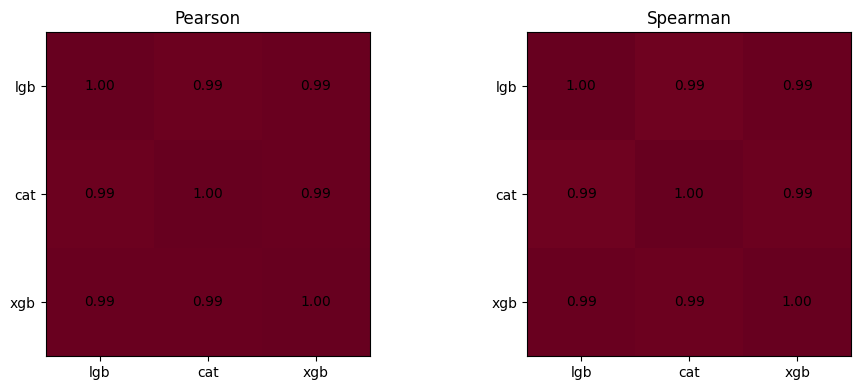


최저 Spearman 쌍: ('lgb', 'cat') = 0.988  → 블렌딩 이득 큰 조합


In [6]:
P=pd.DataFrame(oof).corr()
S=pd.DataFrame(oof).corr(method="spearman")
print("Pearson:\n",P.round(3).to_string())
print("\nSpearman(★):\n",S.round(3).to_string())

fig,ax=plt.subplots(1,2,figsize=(10,4))
for a,(M,t) in zip(ax,[(P,"Pearson"),(S,"Spearman")]):
    im=a.imshow(M,cmap="RdBu_r",vmin=0,vmax=1)
    a.set_xticks(range(3)); a.set_xticklabels(M.columns); a.set_yticks(range(3)); a.set_yticklabels(M.columns)
    for i in range(3):
        for j in range(3): a.text(j,i,f"{M.iloc[i,j]:.2f}",ha="center",va="center")
    a.set_title(t)
plt.tight_layout(); plt.show()
off=S.where(~np.eye(3,dtype=bool)).stack()
print(f"\n최저 Spearman 쌍: {off.idxmin()} = {off.min():.3f}  → 블렌딩 이득 큰 조합")

## 7. STAGE C1 — 힐클라이밍 블렌드

최강 단일에서 시작 → OOF AUC가 **오를 때만** 모델을 가중 추가(Caruana). 3모델이라 전수 simplex 그리드로 교차확인까지.

In [7]:
def hill_climb(oof,y,n_iter=100):
    names=list(oof); single={n:roc_auc_score(y,oof[n]) for n in names}
    best0=max(single,key=single.get)
    ens=[best0]; sums=oof[best0].copy()
    snaps=[(list(ens), roc_auc_score(y,sums/len(ens)))]
    for _ in range(n_iter):
        cb,ca=None,-1
        for n in names:
            a=roc_auc_score(y,(sums+oof[n])/(len(ens)+1))
            if a>ca: ca,cb=a,n
        ens.append(cb); sums=sums+oof[cb]
        snaps.append((list(ens), roc_auc_score(y,sums/len(ens))))
    best_ens,best_auc=max(snaps,key=lambda t:t[1])
    from collections import Counter; c=Counter(best_ens)
    return {n:c.get(n,0)/len(best_ens) for n in names}, best_auc, best0, single

w,blend_hc,best0,single=hill_climb(oof,y)
print("힐클라이밍 가중치:", {k:round(v,3) for k,v in w.items()})
print(f"  블렌드 OOF={blend_hc:.5f} | 최강단일({best0})={single[best0]:.5f} | Δ={blend_hc-single[best0]:+.5f}")

# 전수 simplex 그리드(step 0.05) 교차확인
names=list(oof); grid=np.arange(0,1.0001,0.05); best_g=(None,-1)
for a in grid:
    for b in grid:
        if a+b>1: continue
        cvec=a*oof[names[0]]+b*oof[names[1]]+(1-a-b)*oof[names[2]]
        au=roc_auc_score(y,cvec)
        if au>best_g[1]: best_g=({names[0]:float(round(a,2)),names[1]:float(round(b,2)),names[2]:float(round(1-a-b,2))},au)
print(f"\n전수그리드 최적: {best_g[0]} | OOF={best_g[1]:.5f}")

W=w  # 힐클라이밍 가중치 채택 (그리드와 일치 확인)
delta=blend_hc-single[best0]
print(f"\n★ 게이트: 블렌드 Δ={delta:+.5f} vs 잡음(±0.0002) → {'채택 후보(LB 확인)' if delta>0.0003 else '이득 미미 — LB로 신중 확인'}")

힐클라이밍 가중치: {'lgb': 0.328, 'cat': 0.414, 'xgb': 0.259}
  블렌드 OOF=0.74013 | 최강단일(xgb)=0.73961 | Δ=+0.00052

전수그리드 최적: {'lgb': 0.35, 'cat': 0.4, 'xgb': 0.25} | OOF=0.74013

★ 게이트: 블렌드 Δ=+0.00052 vs 잡음(±0.0002) → 채택 후보(LB 확인)


## 8. 제출 파일 (블렌드 + 단일 — LB A/B용)

In [8]:
def write_sub(pred, name):
    s=sample_sub.copy() if sample_sub is not None else pd.DataFrame({ID_COL:ids})
    pc=[c for c in s.columns if c!=ID_COL]; pc=pc[0] if pc else "probability"
    pm=dict(zip(ids,pred))
    if ID_COL in s.columns: s[pc]=s[ID_COL].map(pm)
    else: s[ID_COL]=ids; s[pc]=pred
    s.to_csv(name,index=False); return s,pc

test_blend=sum(W[m]*tst[m] for m in W)
sub,pc=write_sub(test_blend,"submission.csv")
for m in tst: write_sub(tst[m], f"submission_{m}.csv")
print("submission.csv(블렌드) 저장:", sub.shape, "| 결측", int(sub[pc].isna().sum()))
print("단일 제출도 저장: submission_lgb/cat/xgb.csv (LB에서 블렌드>단일 확인용)")
sub.head()

submission.csv(블렌드) 저장: (90067, 2) | 결측 0
단일 제출도 저장: submission_lgb/cat/xgb.csv (LB에서 블렌드>단일 확인용)


,ID,probability
0,TEST_00000,0.001806
1,TEST_00001,0.005550
2,TEST_00002,0.153435
3,TEST_00003,0.105150
4,TEST_00004,0.507388


## 9. 다음 게이트

- **A1과 교차:** baseline + 블렌드 + 단일 3개를 **LB에 제출**해서 *블렌드 OOF Δ가 LB에서도 재현되는지* 확인. 재현되면 채택, 아니면 OOF 과적합 의심.
- **C2 스태킹(블렌드가 먹히면):** `oof_predictions.csv` 위에서 L2 로지스틱 학습(OOF 기반, in-fold 아님 → 누수 방지). 비선형 결합이 가중평균을 이기는지.
- **D 튜닝(병행):** 각 모델 가볍게 튜닝 → 멤버 강화 후 블렌드 재실행. multi-seed `Δ>std`만 채택.
- **현실치:** 블렌드 기대 마진 **+0.002~0.005**. 이 대회는 이 폭으로 갈림.

> ⚠️ FULL 실행은 3모델×5fold라 케글 CPU 20~40분. 처음엔 `FAST=True`로 방향만 보고, 확정 시 FULL.